# Using Lysimeter Data in Stress-Response Experiment to Predict Water Use Efficiency in Camelina Cultivars
## William B, Nibir N, and Brianne S
### CMPT/PLSC 878​
### ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

Import statements:

In [12]:
# Imports for the notebook
import os
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

Directory/File Name settings

In [13]:
dataset_directory = "CamelinaMAGIC-Dataset-Complete/"
all_biomass_file = "CamelinaMAGIC-ALL-Biomass.xlsx"
MAGIC1_daily_transpiration_file = "CamelinaMAGIC1.0-DailyTranspiration.csv"
MAGIC1_weight_raw = "CamelinaMAGIC1.0-WeightRaw.csv"

output_directory = "output/"

Dataset Visualization Code:

Reads biomass workbook and draw a parallel-coordinates plot for pots 1-50

read_biomass_workbook: selected sheet 'Sheet1' with 10 columns
columns: ['Experiment', 'Name', 'Genotype', 'Treatment', 'Fresh Root mass', 'Fresh Total mass', 'Fresh Shoot mass', 'Dry Root mass', 'Dry Total mass', 'Dry Shoot mass']
get_start_weights_from_weightraw: found 50 pots (sample):
    Pot  StartWeight
0    1      6862.24
1    2      6970.28
2    3      6783.89
3    4      6776.30
4    5      7005.29
build_biomass_dataframe: using pot column 'Name'
detected columns -> Fresh Shoot mass Fresh Root mass Fresh Total mass
Tidy dataframe sample:
   Pot  StartWeight  FreshShoot  FreshRoot  FreshTotal
0    1      6862.24        41.2       29.7        70.9
1    1      6862.24        72.9       19.2        92.1
2    1      6862.24        36.9       39.2        76.1
3    2      6970.28        84.7       37.9       122.6
4    2      6970.28        79.2       30.8       110.0
Saved parallel-coordinates plot to output/parallel_coords_MAGIC1_start_end_fresh.png
Saved parallel-coordinates plot 

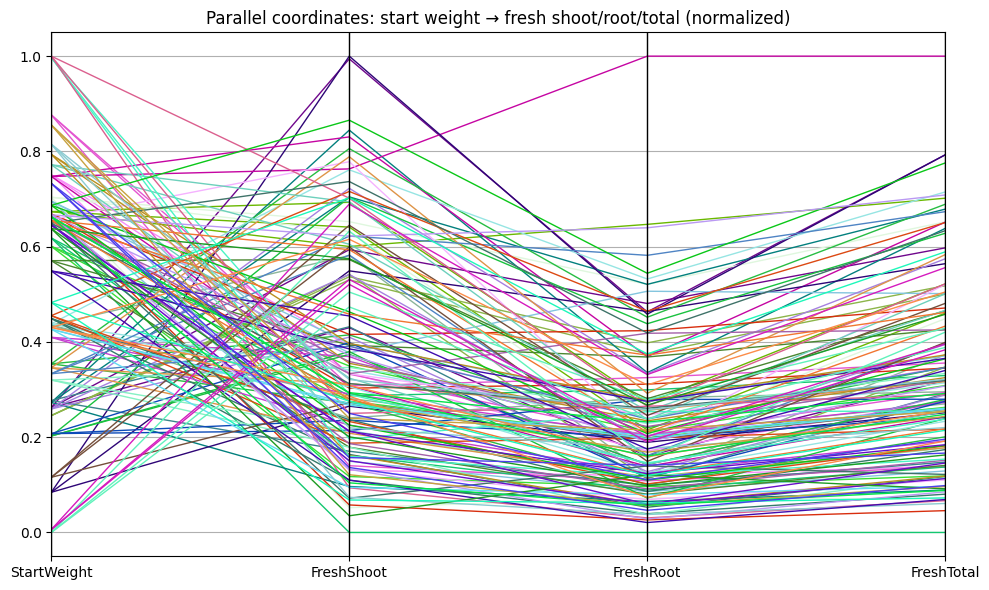

In [14]:
# Use helpers to build the tidy biomass table and plot
import importlib
import helpers
importlib.reload(helpers)
# build absolute paths using the variables already defined above
all_biomass_path = os.path.join(dataset_directory, all_biomass_file)
weight_raw_path = os.path.join(dataset_directory, MAGIC1_weight_raw)
outpath = os.path.join(output_directory, 'parallel_coords_MAGIC1_start_end_fresh.png')

# Read and assemble data
biomass_df = helpers.read_biomass_workbook(all_biomass_path)
start_weights = helpers.get_start_weights_from_weightraw(weight_raw_path)
tidy = helpers.build_biomass_dataframe(biomass_df, start_weights)

# Quick preview and ensure output dir exists
print("Tidy dataframe sample:")
print(tidy.head())
os.makedirs(output_directory, exist_ok=True)

# Plot and save
helpers.plot_parallel_coordinates(tidy, outpath)